In [ ]:
pip install matplotlib

In [3]:
import matplotlib.pyplot as plt
import numpy as np


In [20]:
x = np.random.randint(2,20,7)
y = np.random.randint(30,100,7)
y1 = np.random.randint(30,100,7)
y2 = np.random.randint(30,100,7)

In [22]:
x = [3,4,5,6,9,10,12]
print(x)
print(y)

[3, 4, 5, 6, 9, 10, 12]
[74 38 37 40 64 96 46]


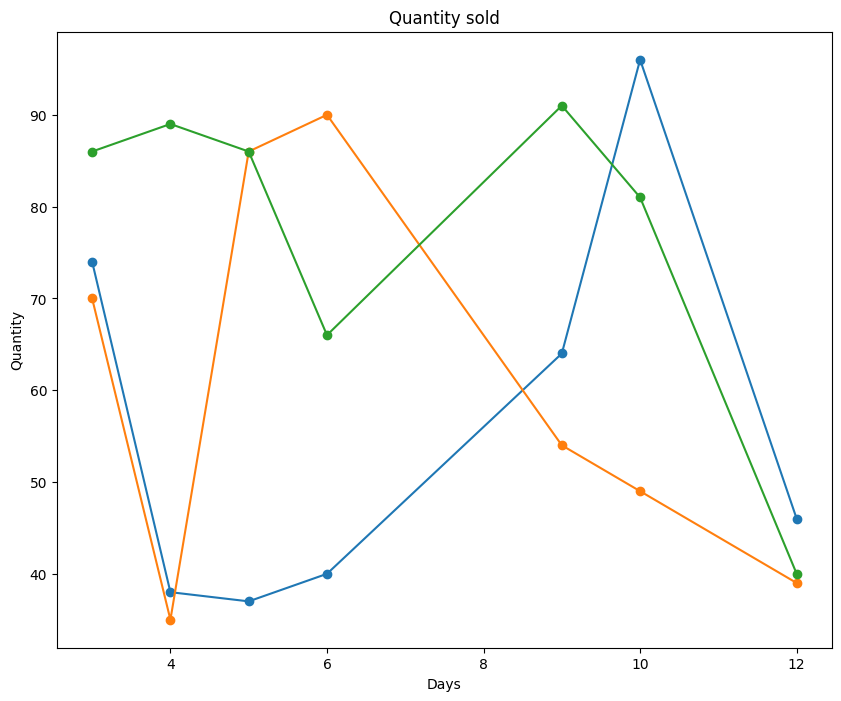

In [34]:
plt.figure(figsize=(10,8))
plt.plot(x,y,marker="o",label="y")
plt.plot(x,y1,marker="o",label="y1")
plt.plot(x,y2,marker="o",label="y2")
plt.xlabel("Days")
plt.ylabel("Quantity")
plt.title("Quantity sold")
plt.show()

In [49]:
c = [1,2,3,4,5,6,7]

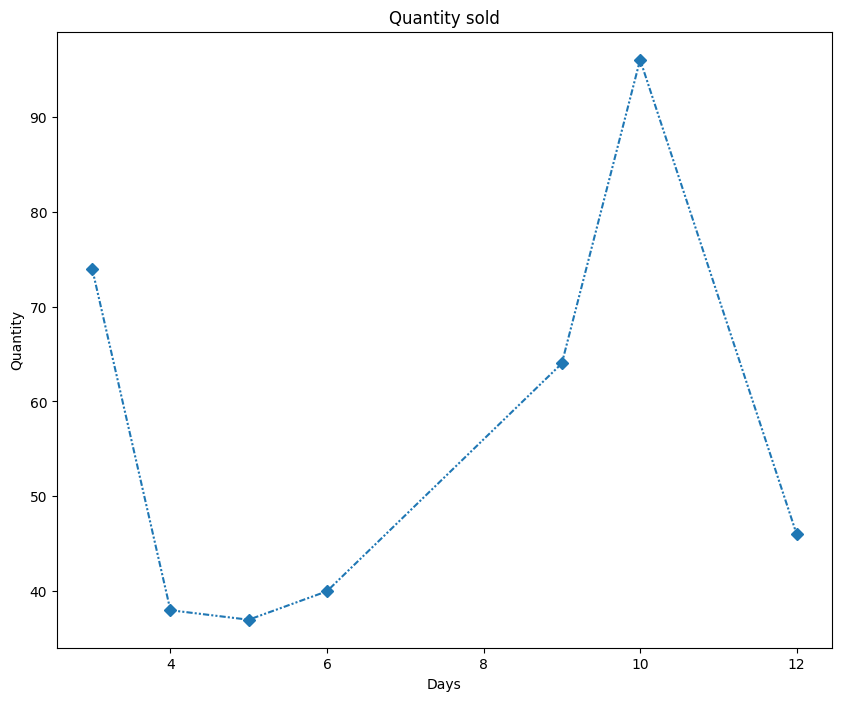

In [52]:
plt.figure(figsize=(10,8))
plt.plot(x,y,marker="D",linestyle=(0,(3,1,1,1,1,1)))
plt.xlabel("Days")
plt.ylabel("Quantity")
plt.title("Quantity sold")
plt.show()

In [ ]:
plt,ax = plt.subplots()

In [57]:

ax.colored_line(x,y,marker="D",linestyle=(0,(3,1,1,1,1,1)),c=c,cmap='rainbow')
plt.xlabel("Days")
plt.ylabel("Quantity")
plt.title("Quantity sold")
plt.show()

AttributeError: 'Axes' object has no attribute 'colored_line'

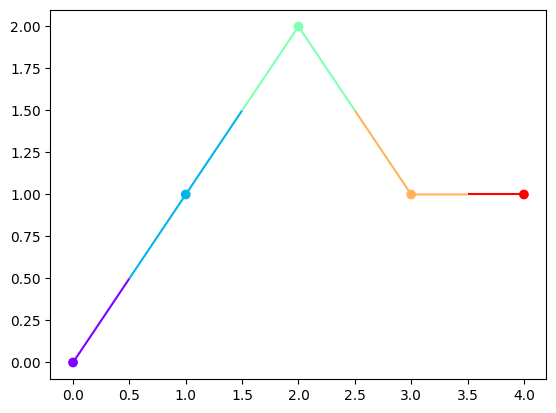

In [59]:
x = [0, 1, 2, 3, 4]
y = [0, 1, 2, 1, 1]
c = [1, 2, 3, 4, 5]
fig, ax = plt.subplots()
ax.scatter(x, y, c=c, cmap='rainbow')
colored_line(x, y, c=c, ax=ax, cmap='rainbow')

plt.show()

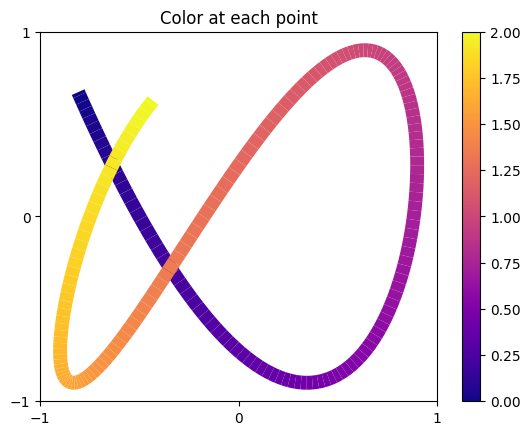

In [58]:
import warnings

import matplotlib.pyplot as plt
import numpy as np

from matplotlib.collections import LineCollection


def colored_line(x, y, c, ax, **lc_kwargs):
    """
    Plot a line with a color specified along the line by a third value.

    It does this by creating a collection of line segments. Each line segment is
    made up of two straight lines each connecting the current (x, y) point to the
    midpoints of the lines connecting the current point with its two neighbors.
    This creates a smooth line with no gaps between the line segments.

    Parameters
    ----------
    x, y : array-like
        The horizontal and vertical coordinates of the data points.
    c : array-like
        The color values, which should be the same size as x and y.
    ax : Axes
        Axis object on which to plot the colored line.
    **lc_kwargs
        Any additional arguments to pass to matplotlib.collections.LineCollection
        constructor. This should not include the array keyword argument because
        that is set to the color argument. If provided, it will be overridden.

    Returns
    -------
    matplotlib.collections.LineCollection
        The generated line collection representing the colored line.
    """
    if "array" in lc_kwargs:
        warnings.warn('The provided "array" keyword argument will be overridden')

    # Default the capstyle to butt so that the line segments smoothly line up
    default_kwargs = {"capstyle": "butt"}
    default_kwargs.update(lc_kwargs)

    # Compute the midpoints of the line segments. Include the first and last points
    # twice so we don't need any special syntax later to handle them.
    x = np.asarray(x)
    y = np.asarray(y)
    x_midpts = np.hstack((x[0], 0.5 * (x[1:] + x[:-1]), x[-1]))
    y_midpts = np.hstack((y[0], 0.5 * (y[1:] + y[:-1]), y[-1]))

    # Determine the start, middle, and end coordinate pair of each line segment.
    # Use the reshape to add an extra dimension so each pair of points is in its
    # own list. Then concatenate them to create:
    # [
    #   [(x1_start, y1_start), (x1_mid, y1_mid), (x1_end, y1_end)],
    #   [(x2_start, y2_start), (x2_mid, y2_mid), (x2_end, y2_end)],
    #   ...
    # ]
    coord_start = np.column_stack((x_midpts[:-1], y_midpts[:-1]))[:, np.newaxis, :]
    coord_mid = np.column_stack((x, y))[:, np.newaxis, :]
    coord_end = np.column_stack((x_midpts[1:], y_midpts[1:]))[:, np.newaxis, :]
    segments = np.concatenate((coord_start, coord_mid, coord_end), axis=1)

    lc = LineCollection(segments, **default_kwargs)
    lc.set_array(c)  # set the colors of each segment

    return ax.add_collection(lc)


# -------------- Create and show plot --------------
# Some arbitrary function that gives x, y, and color values
t = np.linspace(-7.4, -0.5, 200)
x = 0.9 * np.sin(t)
y = 0.9 * np.cos(1.6 * t)
color = np.linspace(0, 2, t.size)

# Create a figure and plot the line on it
fig1, ax1 = plt.subplots()
lines = colored_line(x, y, color, ax1, linewidth=10, cmap="plasma")
fig1.colorbar(lines)  # add a color legend

# Set the axis limits and tick positions
ax1.set_xlim(-1, 1)
ax1.set_ylim(-1, 1)
ax1.set_xticks((-1, 0, 1))
ax1.set_yticks((-1, 0, 1))
ax1.set_title("Color at each point")

plt.show()

In [69]:
x = np.random.randint(20,50,10)
y = np.random.randint(30,100,10)

In [70]:
hue = np.random.choice([1,2,3],10)

In [71]:
y

array([87, 96, 58, 74, 97, 32, 98, 80, 88, 35])

In [72]:
x

array([41, 38, 38, 46, 22, 34, 33, 24, 32, 46])

In [73]:
hue

array([1, 3, 3, 1, 3, 2, 1, 3, 1, 2])

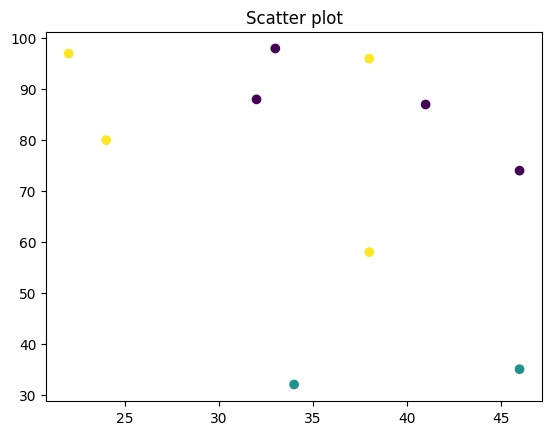

In [ ]:
plt.scatter(x,y,c=hue)
plt.title("Scatter plot")
plt.show()

Bar plot

In [77]:
category = ["Finanace","Sales","HR","Research","Tech"]

In [82]:
expenditure = np.random.randint(30000,200000,5)

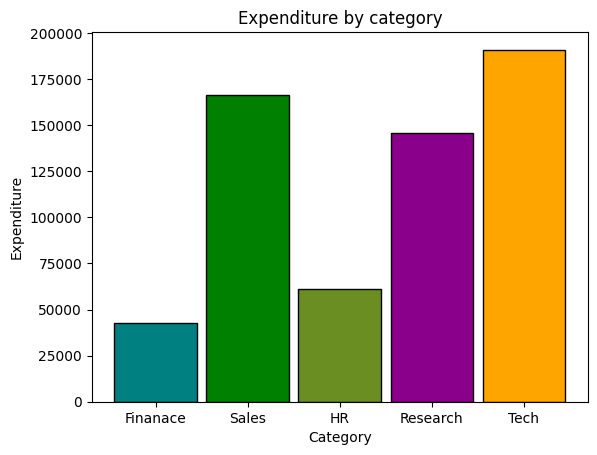

In [ ]:
plt.bar(category,expenditure,width=0.9,color=["teal","green","olivedrab","darkmagenta","orange"],edgecolor='black')
plt.xlabel("Category")
plt.ylabel("Expenditure")
plt.title("Expenditure by category")
plt.show()

Hbar

AttributeError: Rectangle.set() got an unexpected keyword argument 'shadow'

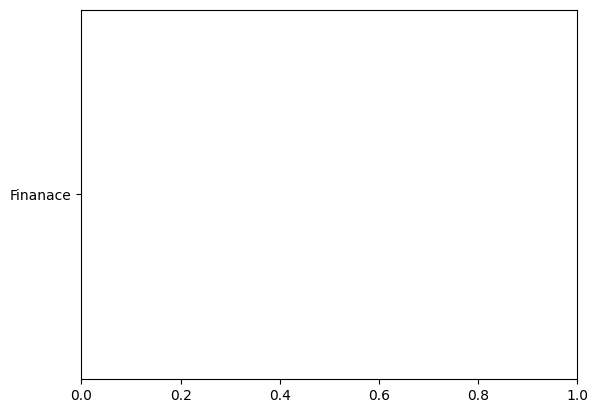

In [ ]:
plt.barh(category,expenditure,height=0.7,color=["teal","green","olivedrab","darkmagenta","orange"])
plt.xlabel("Expenditure")
plt.ylabel("Category")
plt.title("Expenditure by category")
plt.show()

In [ ]:
plt.bar

Histogram

In [116]:
data=np.random.randn(1000)
data = np.random.choice([20,40,250,400,150,350],1000)
data = np.random.randint(20,40,1000)

In [117]:
data

array([31, 39, 30, 36, 36, 27, 27, 30, 35, 34, 30, 25, 26, 29, 27, 28, 32,
       29, 20, 36, 36, 26, 26, 33, 35, 28, 36, 37, 34, 36, 22, 32, 21, 38,
       31, 29, 32, 27, 28, 20, 25, 29, 24, 37, 39, 31, 34, 23, 20, 34, 31,
       31, 31, 20, 35, 28, 25, 25, 25, 23, 26, 20, 28, 26, 24, 33, 30, 27,
       22, 27, 32, 36, 33, 27, 28, 21, 25, 24, 39, 25, 27, 36, 35, 29, 33,
       30, 25, 31, 21, 34, 34, 29, 38, 39, 20, 36, 21, 24, 32, 39, 34, 38,
       21, 29, 24, 34, 33, 26, 34, 33, 28, 31, 22, 37, 27, 23, 27, 24, 33,
       35, 38, 30, 35, 21, 29, 37, 39, 20, 30, 26, 24, 30, 26, 20, 29, 24,
       20, 30, 31, 32, 23, 36, 27, 36, 20, 24, 32, 26, 34, 38, 36, 26, 29,
       36, 22, 30, 38, 39, 22, 34, 35, 22, 26, 20, 30, 25, 34, 23, 25, 39,
       31, 30, 35, 37, 33, 36, 27, 37, 33, 27, 35, 20, 37, 20, 20, 37, 36,
       32, 31, 21, 27, 36, 23, 28, 29, 30, 30, 32, 35, 29, 38, 32, 25, 39,
       26, 22, 28, 26, 35, 30, 39, 27, 27, 33, 30, 24, 25, 34, 32, 24, 31,
       30, 36, 29, 30, 35

AttributeError: Rectangle.set() got an unexpected keyword argument 'shadow'

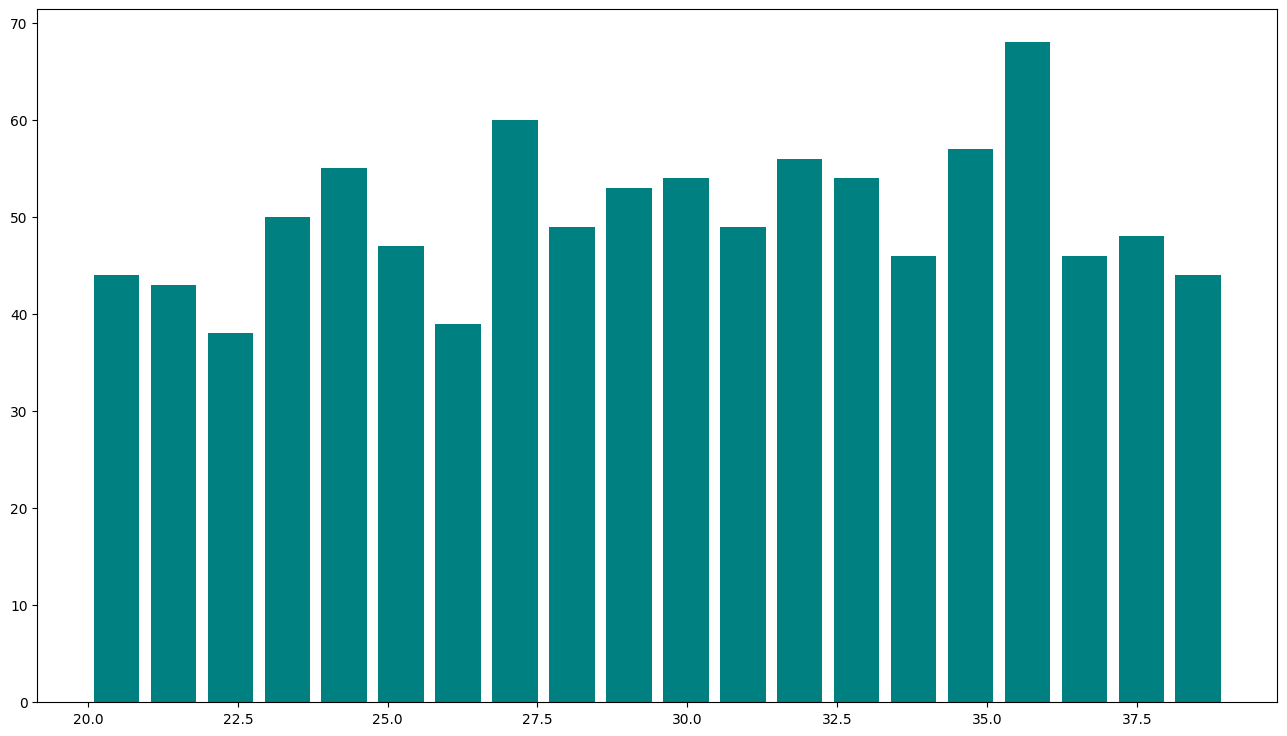

In [ ]:
plt.figure(figsize=(16,9))
plt.hist(data,bins=20,rwidth=0.8,color="teal")
plt.title("Histogram")
plt.show()

Pie Chart

In [121]:
expenditure

array([ 42856, 166165,  61007, 145611, 190844])

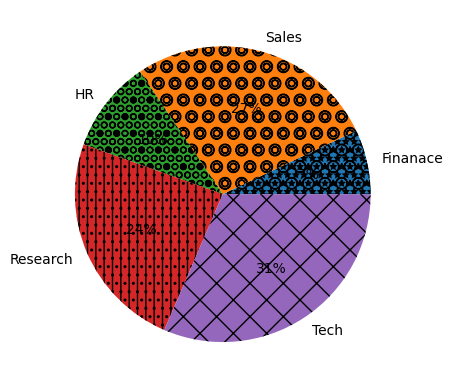

In [127]:
plt.pie(expenditure,labels=category,autopct="%0.0f%%",hatch=['**O', 'oO', 'O.O', '.||.',"x"])
plt.show()

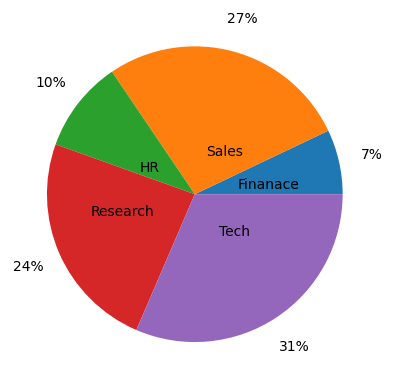

In [132]:
plt.pie(expenditure,labels=category,autopct="%0.0f%%",pctdistance=1.23,labeldistance=0.3)
plt.show()

In [133]:
category

['Finanace', 'Sales', 'HR', 'Research', 'Tech']

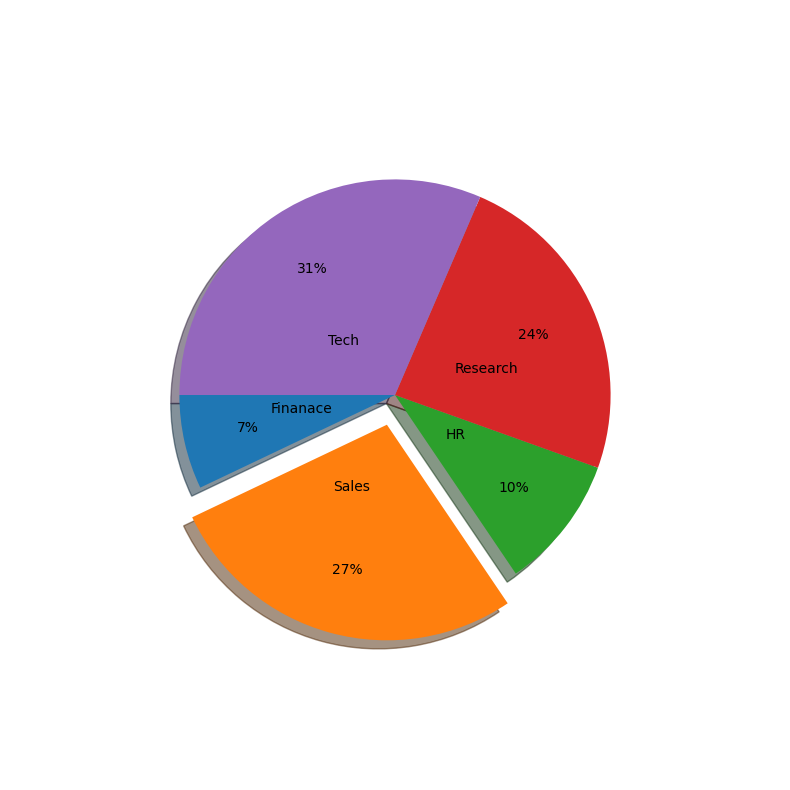

In [144]:
plt.figure(figsize=(10,10))
explode = [0,0.1,0,0,0]
plt.pie(expenditure,
        labels=category,
        autopct="%0.0f%%",
        pctdistance=.7,
        labeldistance=0.3,
        explode=explode,
        shadow=True,
        startangle=180,
        radius=.7)
plt.show()

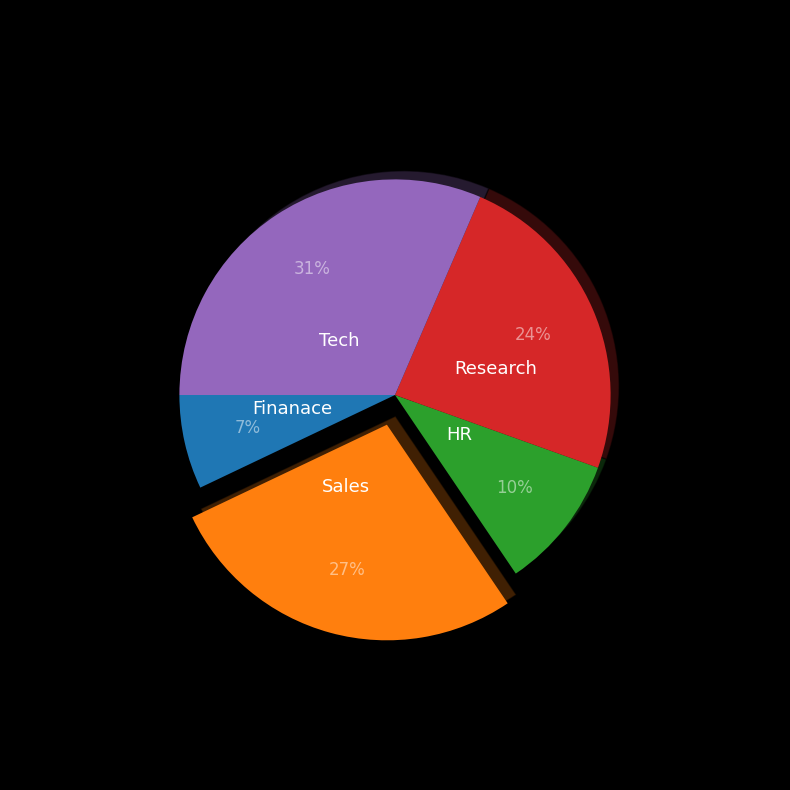

In [162]:
plt.figure(figsize=(10,10),facecolor='black')
explode = [0,0.1,0,0,0]
_,text,autotexts=plt.pie(expenditure,
        labels=category,
        autopct="%0.0f%%",
        pctdistance=.7,
        labeldistance=0.3,
        explode=explode,
        shadow={'ox': 0.02,'oy':0.02, 'edgecolor': 'black', 'shade': 0.5},
        startangle=180,
        radius=.7)

for tx in text:
    tx.set_color('white')
    tx.set_fontsize(13)
for at in autotexts:
    at.set_color('white')
    at.set_fontsize(12)
    at.set_alpha(0.5)
plt.show()

Box plot

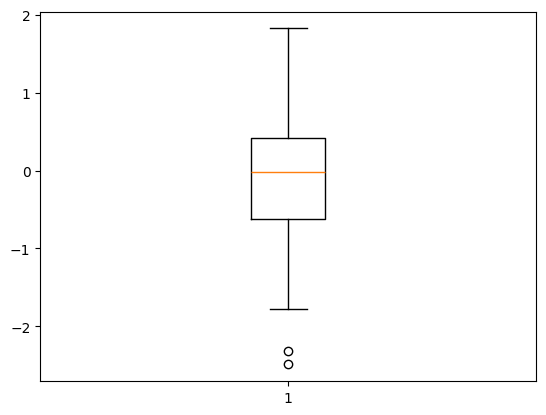

In [166]:
data = [np.random.randn(100)]
plt.boxplot(data)
plt.show()

In [169]:
data

[array([-8.86255913e-01, -1.78176095e+00,  1.01409135e+00, -6.31681908e-01,
        -5.11413261e-01, -9.46978296e-01,  5.79440549e-01,  2.23102420e-01,
        -1.10267413e-02, -1.23112020e-02,  9.92029985e-02, -1.44275136e+00,
         1.82469506e+00, -4.42223606e-01,  3.61223211e-01,  9.01792810e-01,
         1.38190934e+00, -6.90048983e-01,  1.63712310e-01, -1.31540601e+00,
        -1.70332513e-02, -6.12663798e-01, -2.48939895e+00, -7.50424897e-01,
        -8.16547324e-01, -2.68472609e-01, -5.91989592e-01,  4.71021325e-01,
        -1.75763527e+00, -1.80418005e-03, -7.59724435e-01, -1.29197668e+00,
        -1.18057911e-01,  7.10808091e-01, -8.51094438e-01,  2.20759404e-01,
        -1.18818664e-01,  6.88673336e-01,  2.26929816e-01,  1.01083345e-01,
         4.64884155e-01,  3.77438610e-01,  9.51775781e-01,  8.49985580e-01,
        -1.34711554e-01,  1.66606372e+00,  5.72269473e-01,  1.66803824e-01,
        -1.23781844e+00,  2.58542343e-01,  1.65444986e-01,  1.71043330e-01,
         6.4

Stack plot

In [171]:
x = np.arange(1,6)
y1 = [1,3,2,4,3]
y2 = [2,1,3,2,4]

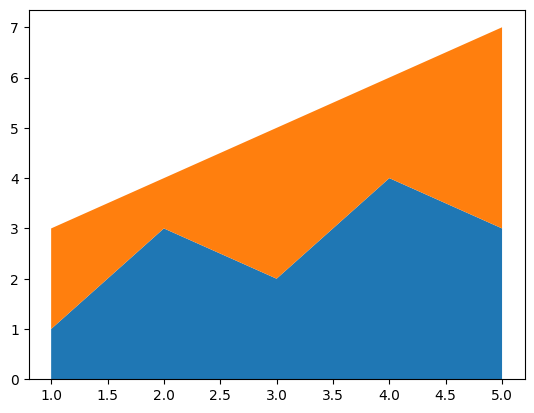

In [173]:
plt.stackplot(x,y1,y2)